In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt, windows
import os

# 导入你修改后的 MVDNet
from model import MVDNet
from main import *

In [2]:
# ==========================================
# 1. 专业信号处理：共振解调与包络谱
# ==========================================
def bandpass_filter(signal, fs=64000, low=2000, high=20000):
    nyq = 0.5 * fs
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def get_envelope_spectrum(signal, fs=64000):
    # 第一步：带通滤波 (提取高频共振带)
    f_sig = bandpass_filter(signal, fs)
    # 第二步：希尔伯特包络
    env = np.abs(hilbert(f_sig))
    env -= np.mean(env) # 去直流
    # 第三步：FFT
    n = len(env)
    freqs = np.fft.fftfreq(n, 1/fs)
    p = np.abs(np.fft.fft(env)) / n
    return freqs[freqs > 0], p[freqs > 0]

# ==========================================
# 2. 模型推理逻辑：使用模型内置的 Mask 接口
# ==========================================
def separate_long_signal(model, raw_sig, device):
    model.eval()
    chunk_size = model.input_len # 直接使用模型定义的长度
    num_chunks = len(raw_sig) // chunk_size
    sep_list = [[] for _ in range(model.K)]

    with torch.no_grad():
        for i in range(num_chunks):
            chunk = raw_sig[i*chunk_size : (i+1)*chunk_size]
            
            # 局部 Z-score 归一化 (必须与训练一致)
            norm_chunk = (chunk - np.mean(chunk)) / (np.std(chunk) + 1e-8)
            x = torch.tensor(norm_chunk, dtype=torch.float32).view(1, 1, -1).to(device)
            
            # 【修改点】调用模型内置的 Mask 分离函数
            # 该函数返回的是一个列表，包含 K 个 (1, 1, L) 的 Tensor
            separated_chunks = model.get_mask_separation(x)
            
            for k in range(model.K):
                # 转回 numpy 并打平
                s_k = separated_chunks[k].cpu().numpy().flatten()
                sep_list[k].append(s_k)
                
    # 拼接所有时间段
    return [np.concatenate(s) for s in sep_list]

# ==========================================
# 3. 绘图主程序（对标论文图 5）
# ==========================================
def plot_final_separation(data_root,save_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 【修改点】初始化模型，input_len 需与训练一致
    model = MVDNet(K=2, input_len=2048).to(device)
    
    # 加载训练好的权重
    model_path = "mvd_net_final.pth"
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"成功加载模型权重: {model_path}")
    else:
        print("警告: 未找到权重文件，将使用随机初始化模型进行测试。")

    # 读取 Task A 真实的复合故障样本 (LA2+LA3: 滚子+外圈)
    target_folder = os.path.join(data_root, 'M0_G0_LA2+LA3_RA0', 'Sample_1')
    
    # 查找符合条件的 CSV 文件
    try:
        file = [f for f in os.listdir(target_folder) if "20Hz_0kN" in f and "leftaxlebox" in f][0]
        df = pd.read_csv(os.path.join(target_folder, file))
    except (IndexError, FileNotFoundError):
        print(f"错误: 在 {target_folder} 下未找到匹配的 CSV 文件。")
        return

    # 取约 1 秒数据 (2048 的倍数) 以获得极致频率分辨率
    # 63488 = 2048 * 31
    raw_signal = df['CH17'].values[:63488] 
    
    # 执行模型分离
    separated_signals = separate_long_signal(model, raw_signal, device)
    # 绘图布局：2x2
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fs = 64000
    
    # Task A 的特征：K=0 通常对应第一个单故障 (Roller), K=1 对应第二个 (Outer Race)
    # 这取决于你训练时 Label 0 和 1 的定义
    titles = ["Separated Component 1 (Roller BF?)", "Separated Component 2 (Outer Race OR?)"]
    fcf_list = [9.7, 23.4] # BJTU 数据集 20Hz 下的理论特征频率

    for k in range(2):
        sig_k = separated_signals[k]
        t = np.arange(len(sig_k)) / fs
        
        # 第一行：时域波形 (截取前 0.5s 显示)
        axes[0, k].plot(t[:32000], sig_k[:32000], color='tab:blue', lw=0.5)
        axes[0, k].set_title(f"{titles[k]} - Time Domain")
        axes[0, k].set_xlabel("Time (s)")
        axes[0, k].set_ylabel("Amplitude")
        axes[0, k].grid(True, alpha=0.3)

        # 第二行：包络谱分析
        f, p = get_envelope_spectrum(sig_k, fs)
        axes[1, k].plot(f, p, color='tab:red', lw=1.0)
        axes[1, k].set_xlim(0, 150) # 关注低频故障特征
        axes[1, k].set_title(f"{titles[k]} - Envelope Spectrum")
        axes[1, k].set_xlabel("Frequency (Hz)")
        axes[1, k].set_ylabel("Magnitude")
        
        # 标注理论特征频率线
        for freq in fcf_list:
            axes[1, k].axvline(freq, color='green', ls='--', alpha=0.4)
        
        # 重点标注当前通道应该寻找的目标频率
        target_f = fcf_list[k]
        axes[1, k].annotate(f'Target: {target_f}Hz', 
                            xy=(target_f, np.max(p)*0.7), 
                            color='darkgreen', weight='bold')
        axes[1, k].grid(True, alpha=0.3)

    plt.suptitle("MVD-Net Reproduction: Compound Fault Separation (Task A)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_dir = "separation_results"   # 想放的文件夹名称

    # 如果文件夹不存在 → 自动创建
    os.makedirs(save_dir, exist_ok=True)
    
    save_path = os.path.join(save_dir, f"reproduced_figure_5_v2_{save_name}.png")
    
    plt.savefig(save_path, dpi=300)
    
    print(f"图像已保存到: {save_path}")
    plt.show()



运行环境: cuda
Epoch [1/100] | Loss: 1.6277 | Rec: 1.5906 | KL: 0.3703
Epoch [2/100] | Loss: 1.5948 | Rec: 1.5857 | KL: 0.0912
Epoch [3/100] | Loss: 1.5858 | Rec: 1.5769 | KL: 0.0889
Epoch [4/100] | Loss: 1.5098 | Rec: 1.4618 | KL: 0.4802
Epoch [5/100] | Loss: 1.3477 | Rec: 1.2451 | KL: 1.0260
Epoch [6/100] | Loss: 1.2156 | Rec: 1.0900 | KL: 1.2566
Epoch [7/100] | Loss: 1.0830 | Rec: 0.9430 | KL: 1.3998
Epoch [8/100] | Loss: 0.9688 | Rec: 0.8152 | KL: 1.5362
Epoch [9/100] | Loss: 0.8774 | Rec: 0.7132 | KL: 1.6427
Epoch [10/100] | Loss: 0.8111 | Rec: 0.6411 | KL: 1.6996
Epoch [11/100] | Loss: 0.7561 | Rec: 0.5815 | KL: 1.7460
Epoch [12/100] | Loss: 0.7094 | Rec: 0.5359 | KL: 1.7356
Epoch [13/100] | Loss: 0.6807 | Rec: 0.5028 | KL: 1.7793
Epoch [14/100] | Loss: 0.6487 | Rec: 0.4699 | KL: 1.7874
Epoch [15/100] | Loss: 0.6208 | Rec: 0.4389 | KL: 1.8189
Epoch [16/100] | Loss: 0.5955 | Rec: 0.4153 | KL: 1.8026
Epoch [17/100] | Loss: 0.5802 | Rec: 0.3973 | KL: 1.8289
Epoch [18/100] | Loss: 0.5600

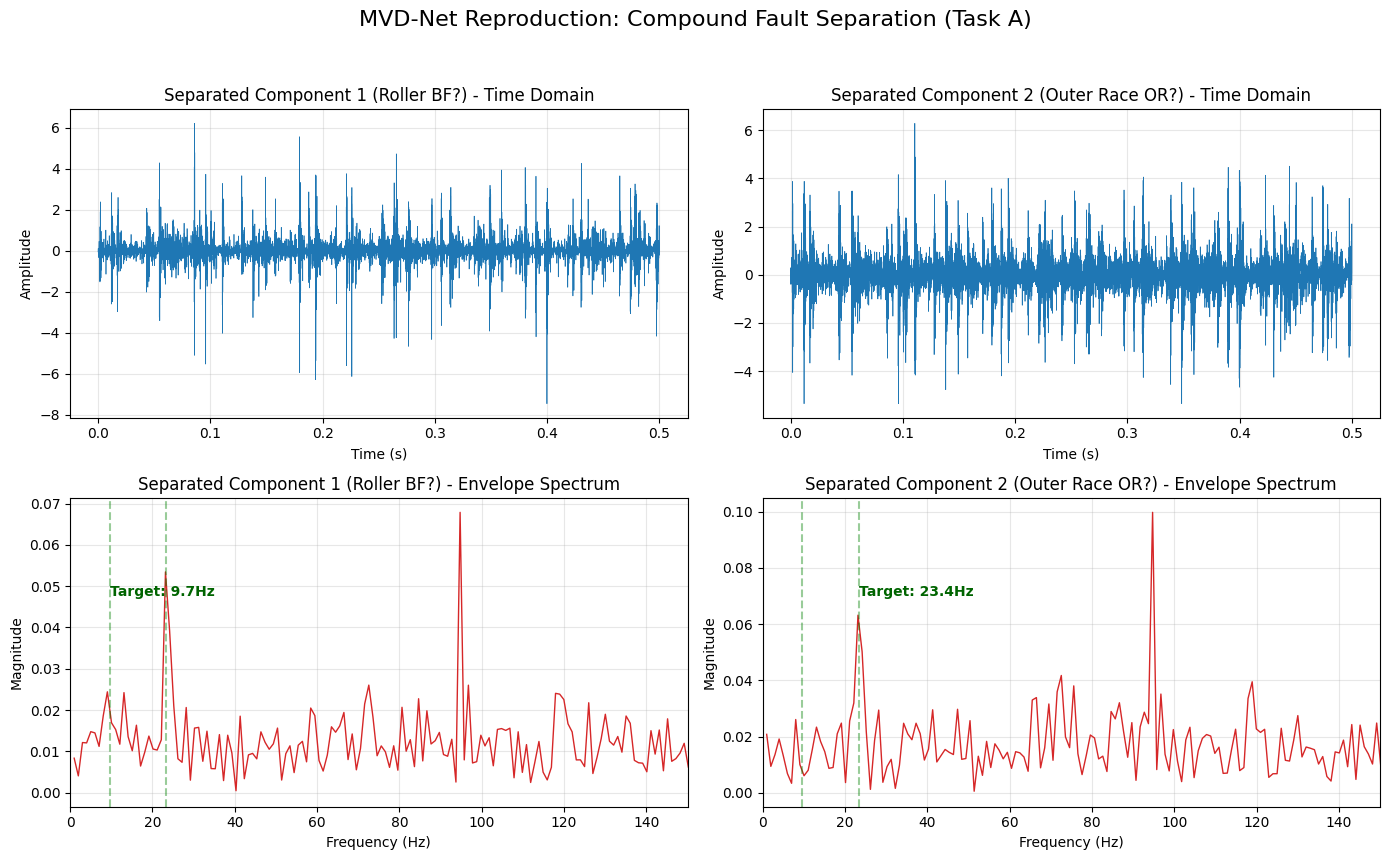

运行环境: cuda
Epoch [1/100] | Loss: 1.6455 | Rec: 1.6079 | KL: 0.3759
Epoch [2/100] | Loss: 1.6118 | Rec: 1.6034 | KL: 0.0839
Epoch [3/100] | Loss: 1.6036 | Rec: 1.5992 | KL: 0.0442
Epoch [4/100] | Loss: 1.6031 | Rec: 1.5979 | KL: 0.0519
Epoch [5/100] | Loss: 1.5599 | Rec: 1.5306 | KL: 0.2924
Epoch [6/100] | Loss: 1.3679 | Rec: 1.2600 | KL: 1.0787
Epoch [7/100] | Loss: 1.1890 | Rec: 1.0443 | KL: 1.4469
Epoch [8/100] | Loss: 1.0356 | Rec: 0.8792 | KL: 1.5640
Epoch [9/100] | Loss: 0.9306 | Rec: 0.7645 | KL: 1.6606
Epoch [10/100] | Loss: 0.8375 | Rec: 0.6673 | KL: 1.7010
Epoch [11/100] | Loss: 0.7782 | Rec: 0.6081 | KL: 1.7012
Epoch [12/100] | Loss: 0.7334 | Rec: 0.5547 | KL: 1.7866
Epoch [13/100] | Loss: 0.6966 | Rec: 0.5197 | KL: 1.7688
Epoch [14/100] | Loss: 0.6673 | Rec: 0.4883 | KL: 1.7898
Epoch [15/100] | Loss: 0.6432 | Rec: 0.4606 | KL: 1.8258
Epoch [16/100] | Loss: 0.6076 | Rec: 0.4242 | KL: 1.8333
Epoch [17/100] | Loss: 0.5895 | Rec: 0.4072 | KL: 1.8223
Epoch [18/100] | Loss: 0.5830

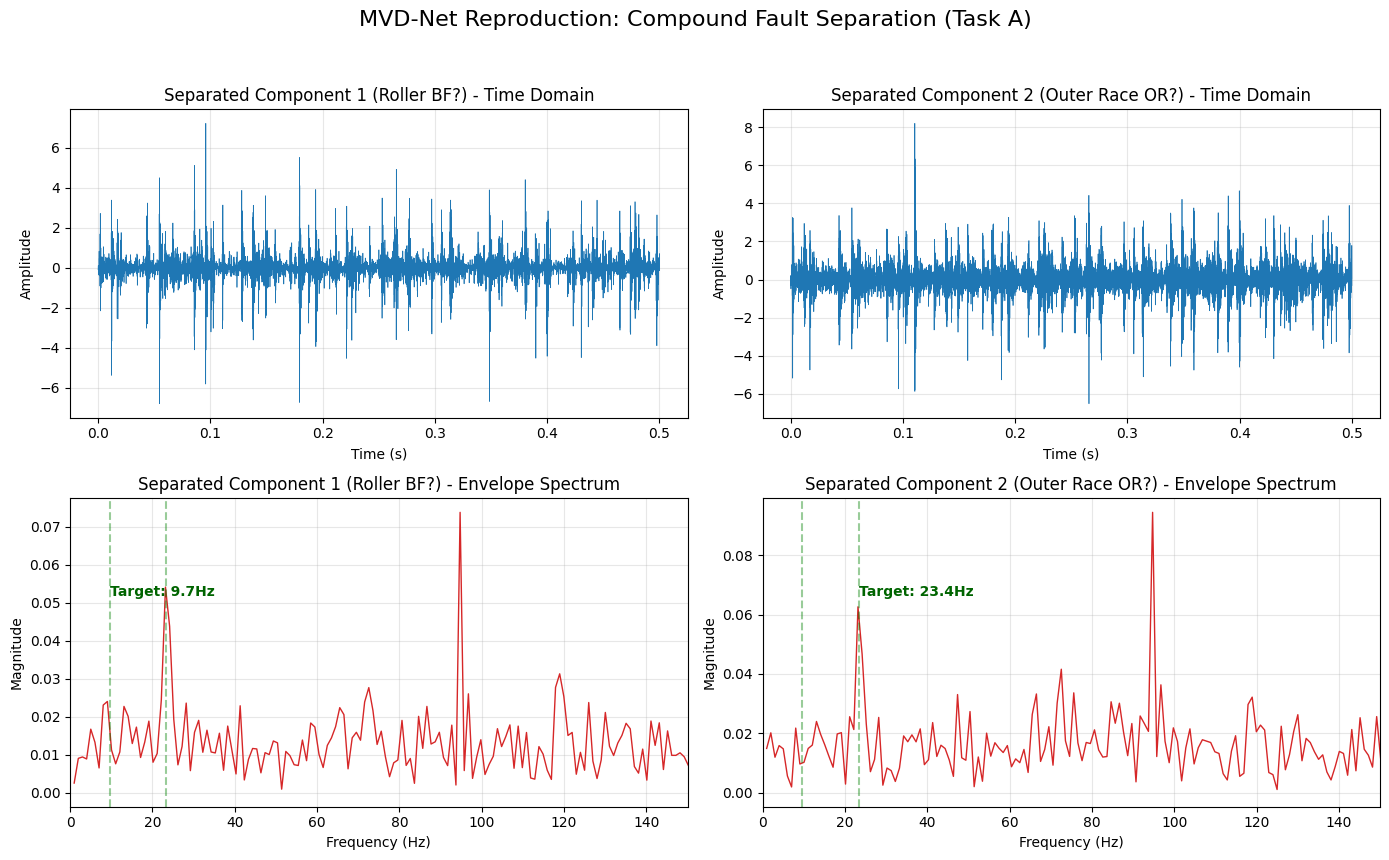

运行环境: cuda
Epoch [1/100] | Loss: 1.6095 | Rec: 1.5748 | KL: 0.3465
Epoch [2/100] | Loss: 1.5653 | Rec: 1.5580 | KL: 0.0729
Epoch [3/100] | Loss: 1.5692 | Rec: 1.5654 | KL: 0.0372
Epoch [4/100] | Loss: 1.5662 | Rec: 1.5610 | KL: 0.0528
Epoch [5/100] | Loss: 1.5138 | Rec: 1.4781 | KL: 0.3568
Epoch [6/100] | Loss: 1.4276 | Rec: 1.3601 | KL: 0.6746
Epoch [7/100] | Loss: 1.3574 | Rec: 1.2752 | KL: 0.8220
Epoch [8/100] | Loss: 1.2707 | Rec: 1.1658 | KL: 1.0485
Epoch [9/100] | Loss: 1.1823 | Rec: 1.0673 | KL: 1.1500
Epoch [10/100] | Loss: 1.0890 | Rec: 0.9591 | KL: 1.2989
Epoch [11/100] | Loss: 0.9856 | Rec: 0.8409 | KL: 1.4472
Epoch [12/100] | Loss: 0.8972 | Rec: 0.7387 | KL: 1.5848
Epoch [13/100] | Loss: 0.8169 | Rec: 0.6542 | KL: 1.6265
Epoch [14/100] | Loss: 0.7629 | Rec: 0.5946 | KL: 1.6833
Epoch [15/100] | Loss: 0.7213 | Rec: 0.5517 | KL: 1.6962
Epoch [16/100] | Loss: 0.6834 | Rec: 0.5064 | KL: 1.7702
Epoch [17/100] | Loss: 0.6435 | Rec: 0.4668 | KL: 1.7673
Epoch [18/100] | Loss: 0.6197

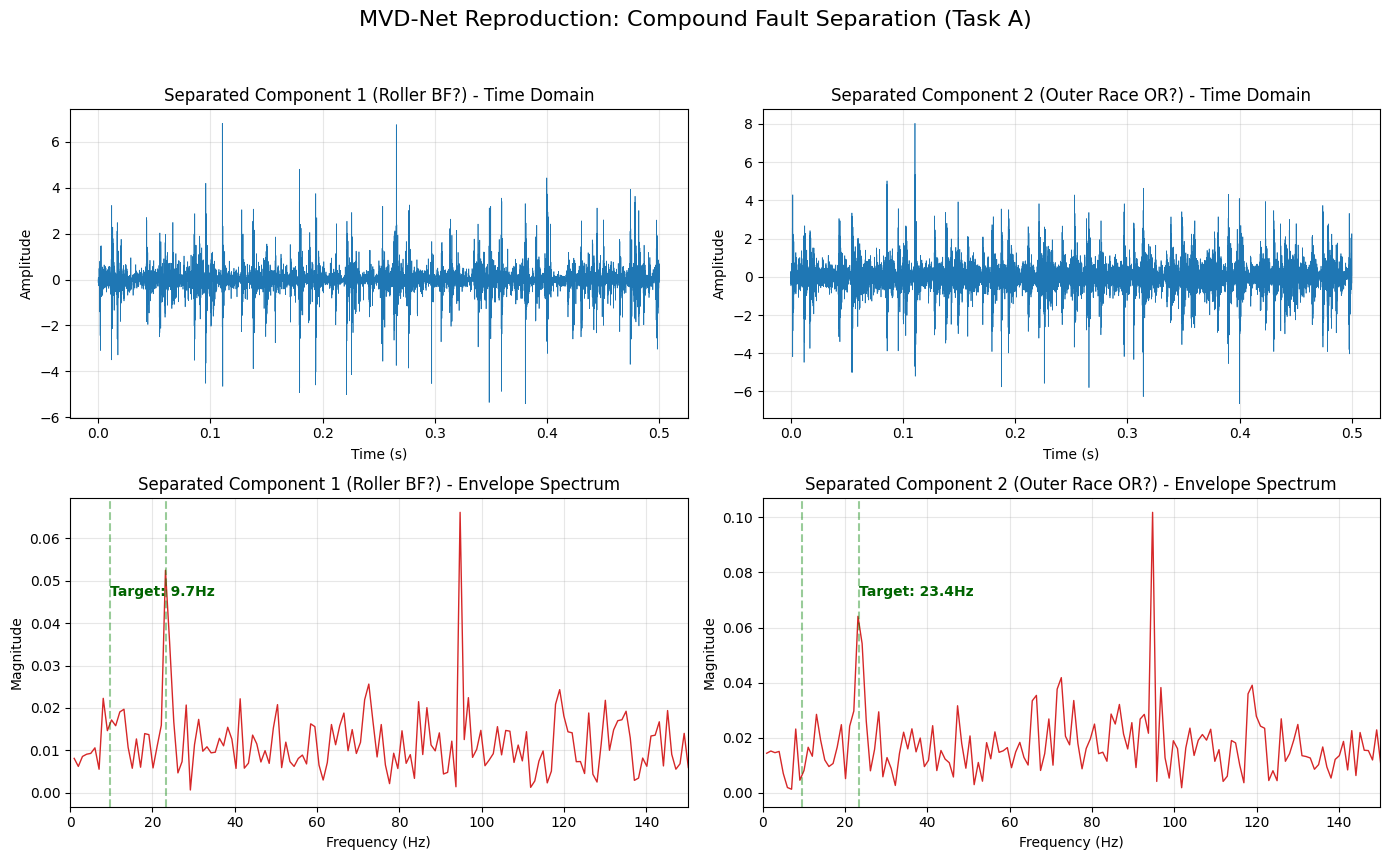

运行环境: cuda
Epoch [1/100] | Loss: 1.6689 | Rec: 1.6359 | KL: 0.3305
Epoch [2/100] | Loss: 1.6263 | Rec: 1.6193 | KL: 0.0701
Epoch [3/100] | Loss: 1.6304 | Rec: 1.6258 | KL: 0.0462
Epoch [4/100] | Loss: 1.6219 | Rec: 1.6114 | KL: 0.1045
Epoch [5/100] | Loss: 1.5008 | Rec: 1.4258 | KL: 0.7502
Epoch [6/100] | Loss: 1.3831 | Rec: 1.2582 | KL: 1.2484
Epoch [7/100] | Loss: 1.1780 | Rec: 1.0325 | KL: 1.4541
Epoch [8/100] | Loss: 1.0587 | Rec: 0.8967 | KL: 1.6200
Epoch [9/100] | Loss: 0.9584 | Rec: 0.7892 | KL: 1.6917
Epoch [10/100] | Loss: 0.8813 | Rec: 0.7039 | KL: 1.7740
Epoch [11/100] | Loss: 0.8320 | Rec: 0.6501 | KL: 1.8185
Epoch [12/100] | Loss: 0.7854 | Rec: 0.6023 | KL: 1.8318
Epoch [13/100] | Loss: 0.7388 | Rec: 0.5506 | KL: 1.8819
Epoch [14/100] | Loss: 0.7068 | Rec: 0.5203 | KL: 1.8643
Epoch [15/100] | Loss: 0.6707 | Rec: 0.4835 | KL: 1.8726
Epoch [16/100] | Loss: 0.6441 | Rec: 0.4567 | KL: 1.8738
Epoch [17/100] | Loss: 0.6191 | Rec: 0.4309 | KL: 1.8826
Epoch [18/100] | Loss: 0.6029

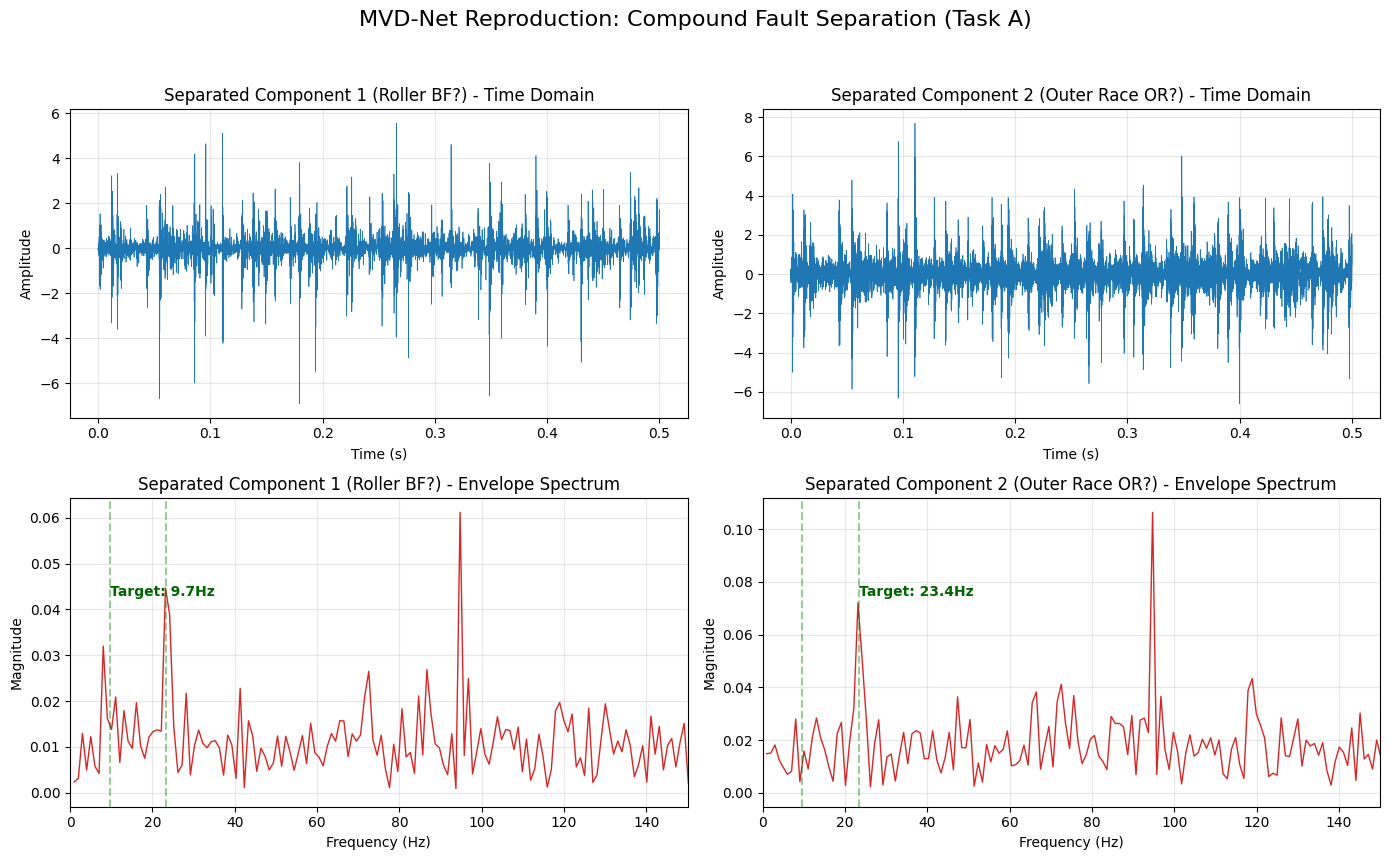

运行环境: cuda
Epoch [1/100] | Loss: 1.6409 | Rec: 1.6045 | KL: 0.3644
Epoch [2/100] | Loss: 1.6051 | Rec: 1.5963 | KL: 0.0874
Epoch [3/100] | Loss: 1.5966 | Rec: 1.5901 | KL: 0.0651
Epoch [4/100] | Loss: 1.5655 | Rec: 1.5461 | KL: 0.1934
Epoch [5/100] | Loss: 1.4414 | Rec: 1.3640 | KL: 0.7739
Epoch [6/100] | Loss: 1.3033 | Rec: 1.1888 | KL: 1.1444
Epoch [7/100] | Loss: 1.1466 | Rec: 1.0058 | KL: 1.4081
Epoch [8/100] | Loss: 1.0051 | Rec: 0.8480 | KL: 1.5708
Epoch [9/100] | Loss: 0.9025 | Rec: 0.7364 | KL: 1.6612
Epoch [10/100] | Loss: 0.8253 | Rec: 0.6542 | KL: 1.7109
Epoch [11/100] | Loss: 0.7762 | Rec: 0.6033 | KL: 1.7287
Epoch [12/100] | Loss: 0.7267 | Rec: 0.5487 | KL: 1.7800
Epoch [13/100] | Loss: 0.6868 | Rec: 0.5066 | KL: 1.8013
Epoch [14/100] | Loss: 0.6549 | Rec: 0.4768 | KL: 1.7811
Epoch [15/100] | Loss: 0.6232 | Rec: 0.4416 | KL: 1.8159
Epoch [16/100] | Loss: 0.6002 | Rec: 0.4182 | KL: 1.8200
Epoch [17/100] | Loss: 0.5780 | Rec: 0.3974 | KL: 1.8059
Epoch [18/100] | Loss: 0.5696

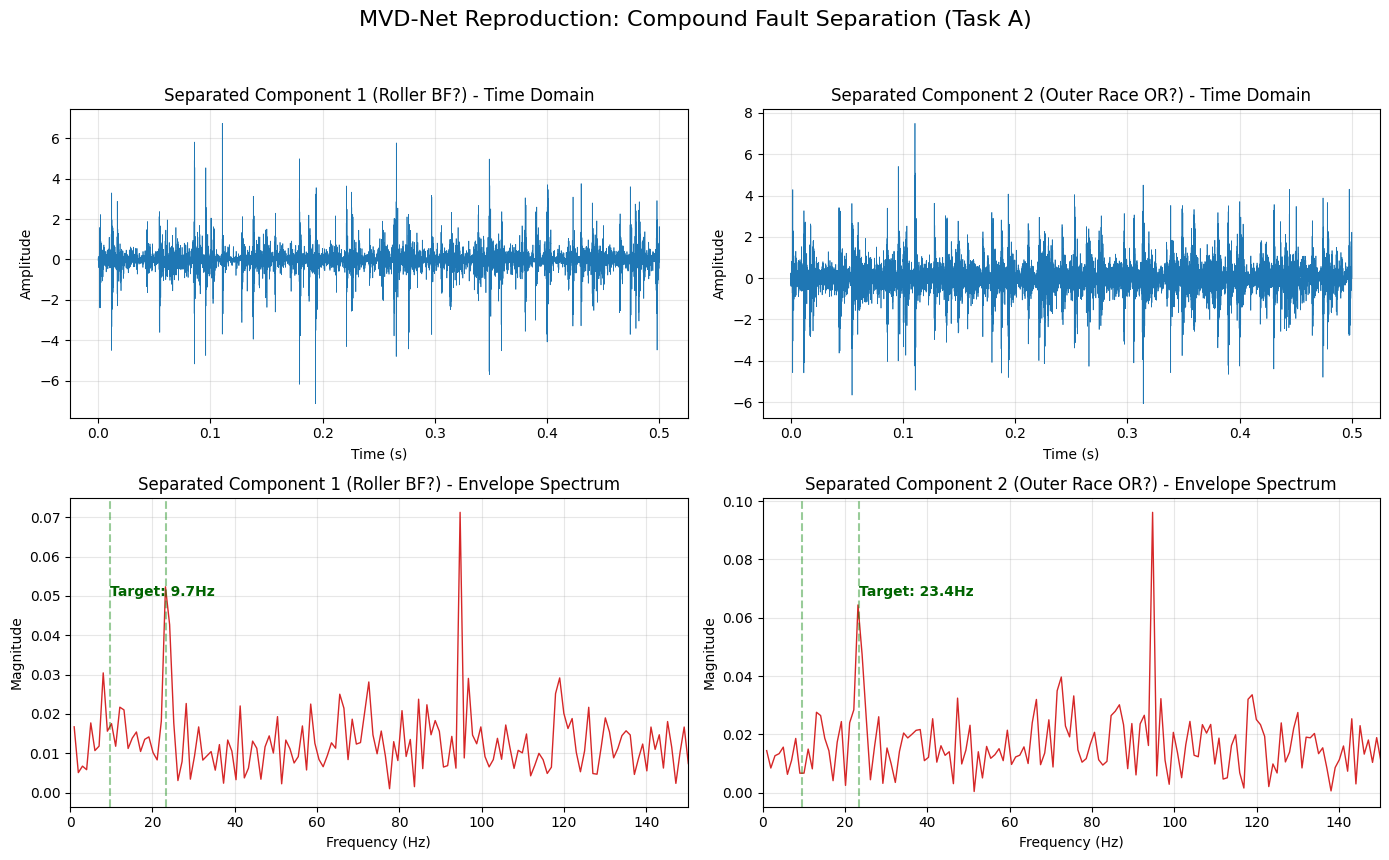

运行环境: cuda
Epoch [1/100] | Loss: 1.6565 | Rec: 1.6213 | KL: 0.3520
Epoch [2/100] | Loss: 1.6264 | Rec: 1.6185 | KL: 0.0788
Epoch [3/100] | Loss: 1.6233 | Rec: 1.6177 | KL: 0.0563
Epoch [4/100] | Loss: 1.5844 | Rec: 1.5641 | KL: 0.2031
Epoch [5/100] | Loss: 1.4642 | Rec: 1.3944 | KL: 0.6976
Epoch [6/100] | Loss: 1.3266 | Rec: 1.2197 | KL: 1.0696
Epoch [7/100] | Loss: 1.1895 | Rec: 1.0573 | KL: 1.3216
Epoch [8/100] | Loss: 1.0703 | Rec: 0.9244 | KL: 1.4597
Epoch [9/100] | Loss: 0.9633 | Rec: 0.8057 | KL: 1.5762
Epoch [10/100] | Loss: 0.8786 | Rec: 0.7168 | KL: 1.6177
Epoch [11/100] | Loss: 0.8085 | Rec: 0.6389 | KL: 1.6967
Epoch [12/100] | Loss: 0.7565 | Rec: 0.5844 | KL: 1.7214
Epoch [13/100] | Loss: 0.7131 | Rec: 0.5377 | KL: 1.7537
Epoch [14/100] | Loss: 0.6761 | Rec: 0.5019 | KL: 1.7423
Epoch [15/100] | Loss: 0.6437 | Rec: 0.4642 | KL: 1.7952
Epoch [16/100] | Loss: 0.6175 | Rec: 0.4353 | KL: 1.8218
Epoch [17/100] | Loss: 0.5993 | Rec: 0.4198 | KL: 1.7952
Epoch [18/100] | Loss: 0.5818

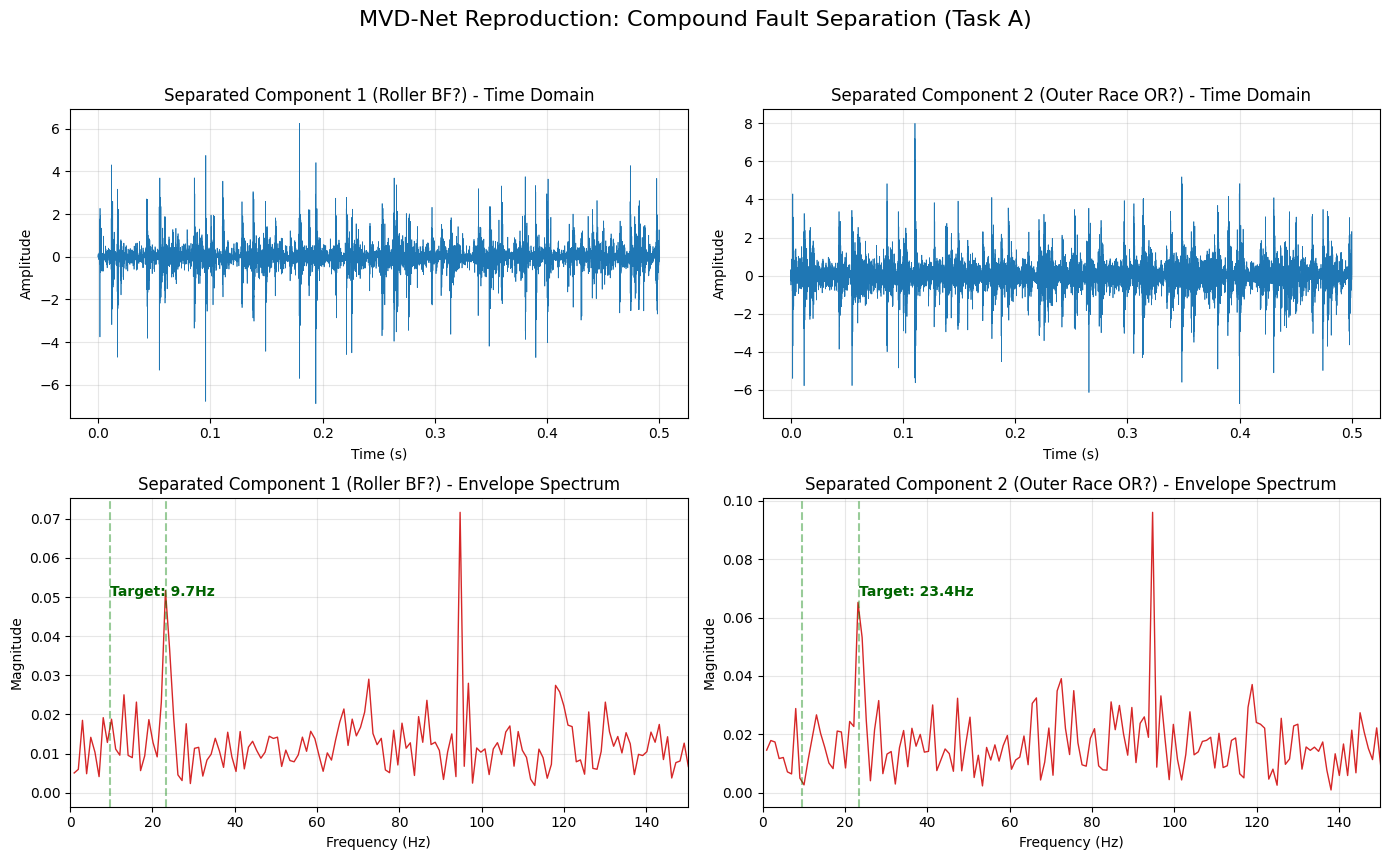

运行环境: cuda
Epoch [1/100] | Loss: 1.6570 | Rec: 1.6204 | KL: 0.3663
Epoch [2/100] | Loss: 1.6193 | Rec: 1.6120 | KL: 0.0731
Epoch [3/100] | Loss: 1.6196 | Rec: 1.6154 | KL: 0.0423
Epoch [4/100] | Loss: 1.6024 | Rec: 1.5962 | KL: 0.0626
Epoch [5/100] | Loss: 1.5325 | Rec: 1.4795 | KL: 0.5296
Epoch [6/100] | Loss: 1.3796 | Rec: 1.2772 | KL: 1.0245
Epoch [7/100] | Loss: 1.2469 | Rec: 1.1234 | KL: 1.2354
Epoch [8/100] | Loss: 1.1069 | Rec: 0.9683 | KL: 1.3858
Epoch [9/100] | Loss: 0.9941 | Rec: 0.8433 | KL: 1.5074
Epoch [10/100] | Loss: 0.9049 | Rec: 0.7446 | KL: 1.6030
Epoch [11/100] | Loss: 0.8310 | Rec: 0.6686 | KL: 1.6244
Epoch [12/100] | Loss: 0.7672 | Rec: 0.5977 | KL: 1.6955
Epoch [13/100] | Loss: 0.7255 | Rec: 0.5533 | KL: 1.7213
Epoch [14/100] | Loss: 0.6931 | Rec: 0.5187 | KL: 1.7436
Epoch [15/100] | Loss: 0.6534 | Rec: 0.4750 | KL: 1.7848
Epoch [16/100] | Loss: 0.6252 | Rec: 0.4452 | KL: 1.7997
Epoch [17/100] | Loss: 0.6018 | Rec: 0.4209 | KL: 1.8092
Epoch [18/100] | Loss: 0.5875

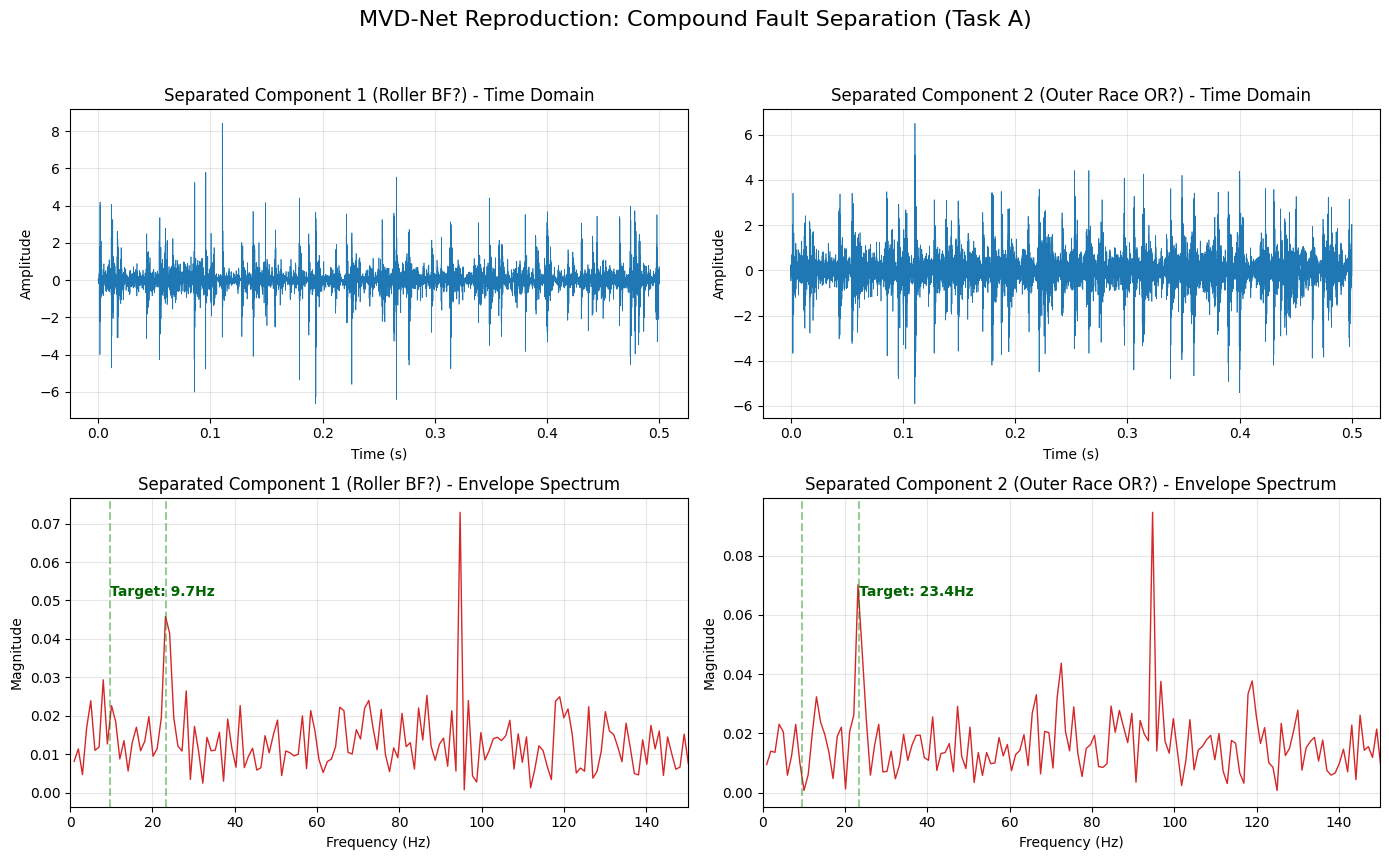

运行环境: cuda
Epoch [1/100] | Loss: 1.6309 | Rec: 1.5944 | KL: 0.3651
Epoch [2/100] | Loss: 1.6000 | Rec: 1.5922 | KL: 0.0785
Epoch [3/100] | Loss: 1.5993 | Rec: 1.5955 | KL: 0.0377
Epoch [4/100] | Loss: 1.5961 | Rec: 1.5920 | KL: 0.0415
Epoch [5/100] | Loss: 1.5661 | Rec: 1.5427 | KL: 0.2345
Epoch [6/100] | Loss: 1.3987 | Rec: 1.3075 | KL: 0.9124
Epoch [7/100] | Loss: 1.2701 | Rec: 1.1470 | KL: 1.2308
Epoch [8/100] | Loss: 1.1201 | Rec: 0.9819 | KL: 1.3823
Epoch [9/100] | Loss: 0.9913 | Rec: 0.8388 | KL: 1.5250
Epoch [10/100] | Loss: 0.9121 | Rec: 0.7529 | KL: 1.5923
Epoch [11/100] | Loss: 0.8426 | Rec: 0.6782 | KL: 1.6443
Epoch [12/100] | Loss: 0.7848 | Rec: 0.6158 | KL: 1.6896
Epoch [13/100] | Loss: 0.7371 | Rec: 0.5649 | KL: 1.7219
Epoch [14/100] | Loss: 0.6914 | Rec: 0.5172 | KL: 1.7418
Epoch [15/100] | Loss: 0.6561 | Rec: 0.4785 | KL: 1.7757
Epoch [16/100] | Loss: 0.6303 | Rec: 0.4501 | KL: 1.8027
Epoch [17/100] | Loss: 0.6098 | Rec: 0.4292 | KL: 1.8064
Epoch [18/100] | Loss: 0.5947

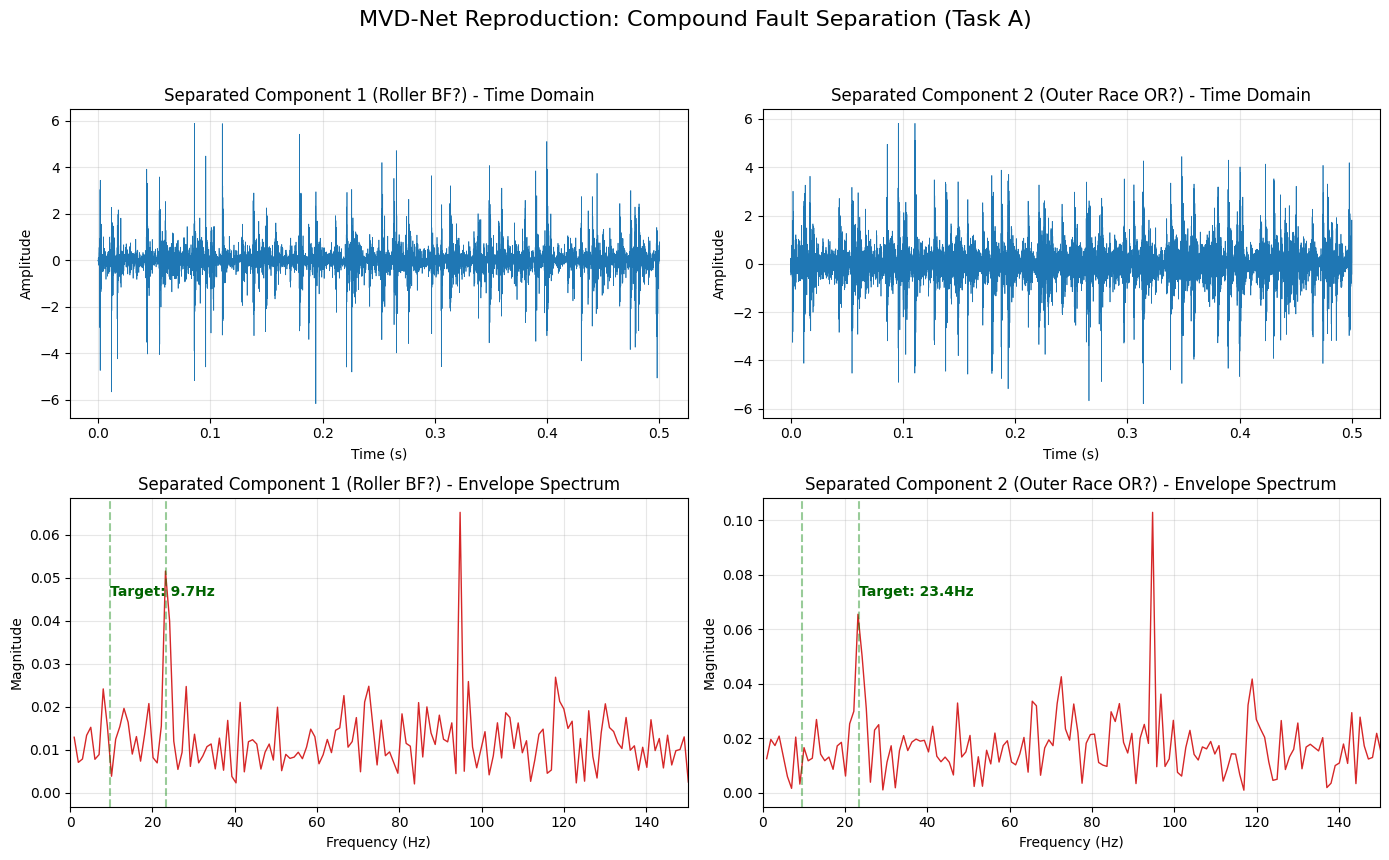

运行环境: cuda
Epoch [1/100] | Loss: 1.6192 | Rec: 1.5888 | KL: 0.3042
Epoch [2/100] | Loss: 1.5945 | Rec: 1.5876 | KL: 0.0686
Epoch [3/100] | Loss: 1.5861 | Rec: 1.5812 | KL: 0.0481
Epoch [4/100] | Loss: 1.5731 | Rec: 1.5627 | KL: 0.1044
Epoch [5/100] | Loss: 1.4401 | Rec: 1.3673 | KL: 0.7283
Epoch [6/100] | Loss: 1.3020 | Rec: 1.1913 | KL: 1.1071
Epoch [7/100] | Loss: 1.1899 | Rec: 1.0647 | KL: 1.2525
Epoch [8/100] | Loss: 1.0789 | Rec: 0.9444 | KL: 1.3453
Epoch [9/100] | Loss: 0.9799 | Rec: 0.8325 | KL: 1.4744
Epoch [10/100] | Loss: 0.8897 | Rec: 0.7319 | KL: 1.5783
Epoch [11/100] | Loss: 0.8132 | Rec: 0.6494 | KL: 1.6381
Epoch [12/100] | Loss: 0.7629 | Rec: 0.5951 | KL: 1.6777
Epoch [13/100] | Loss: 0.7131 | Rec: 0.5407 | KL: 1.7238
Epoch [14/100] | Loss: 0.6746 | Rec: 0.4974 | KL: 1.7720
Epoch [15/100] | Loss: 0.6481 | Rec: 0.4695 | KL: 1.7864
Epoch [16/100] | Loss: 0.6219 | Rec: 0.4414 | KL: 1.8044
Epoch [17/100] | Loss: 0.6041 | Rec: 0.4232 | KL: 1.8085
Epoch [18/100] | Loss: 0.5760

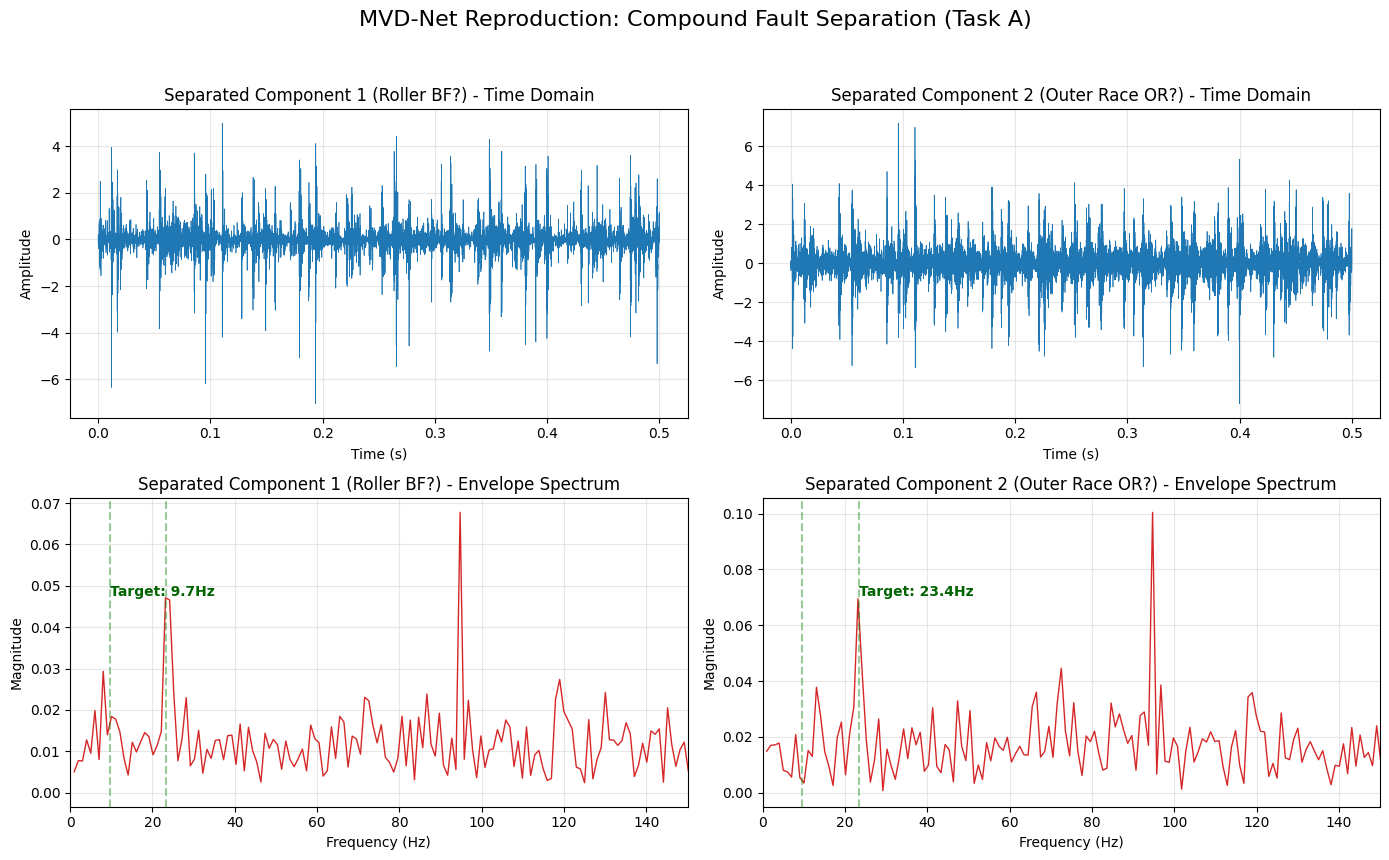

运行环境: cuda
Epoch [1/100] | Loss: 1.6459 | Rec: 1.6097 | KL: 0.3625
Epoch [2/100] | Loss: 1.6021 | Rec: 1.5942 | KL: 0.0796
Epoch [3/100] | Loss: 1.6029 | Rec: 1.5981 | KL: 0.0484
Epoch [4/100] | Loss: 1.5925 | Rec: 1.5842 | KL: 0.0831
Epoch [5/100] | Loss: 1.5268 | Rec: 1.4803 | KL: 0.4652
Epoch [6/100] | Loss: 1.3683 | Rec: 1.2641 | KL: 1.0427
Epoch [7/100] | Loss: 1.2286 | Rec: 1.0997 | KL: 1.2894
Epoch [8/100] | Loss: 1.1144 | Rec: 0.9783 | KL: 1.3603
Epoch [9/100] | Loss: 1.0123 | Rec: 0.8667 | KL: 1.4564
Epoch [10/100] | Loss: 0.9193 | Rec: 0.7633 | KL: 1.5599
Epoch [11/100] | Loss: 0.8383 | Rec: 0.6755 | KL: 1.6282
Epoch [12/100] | Loss: 0.7850 | Rec: 0.6149 | KL: 1.7009
Epoch [13/100] | Loss: 0.7324 | Rec: 0.5608 | KL: 1.7165
Epoch [14/100] | Loss: 0.6897 | Rec: 0.5152 | KL: 1.7450
Epoch [15/100] | Loss: 0.6550 | Rec: 0.4777 | KL: 1.7737
Epoch [16/100] | Loss: 0.6299 | Rec: 0.4488 | KL: 1.8112
Epoch [17/100] | Loss: 0.6062 | Rec: 0.4277 | KL: 1.7847
Epoch [18/100] | Loss: 0.5955

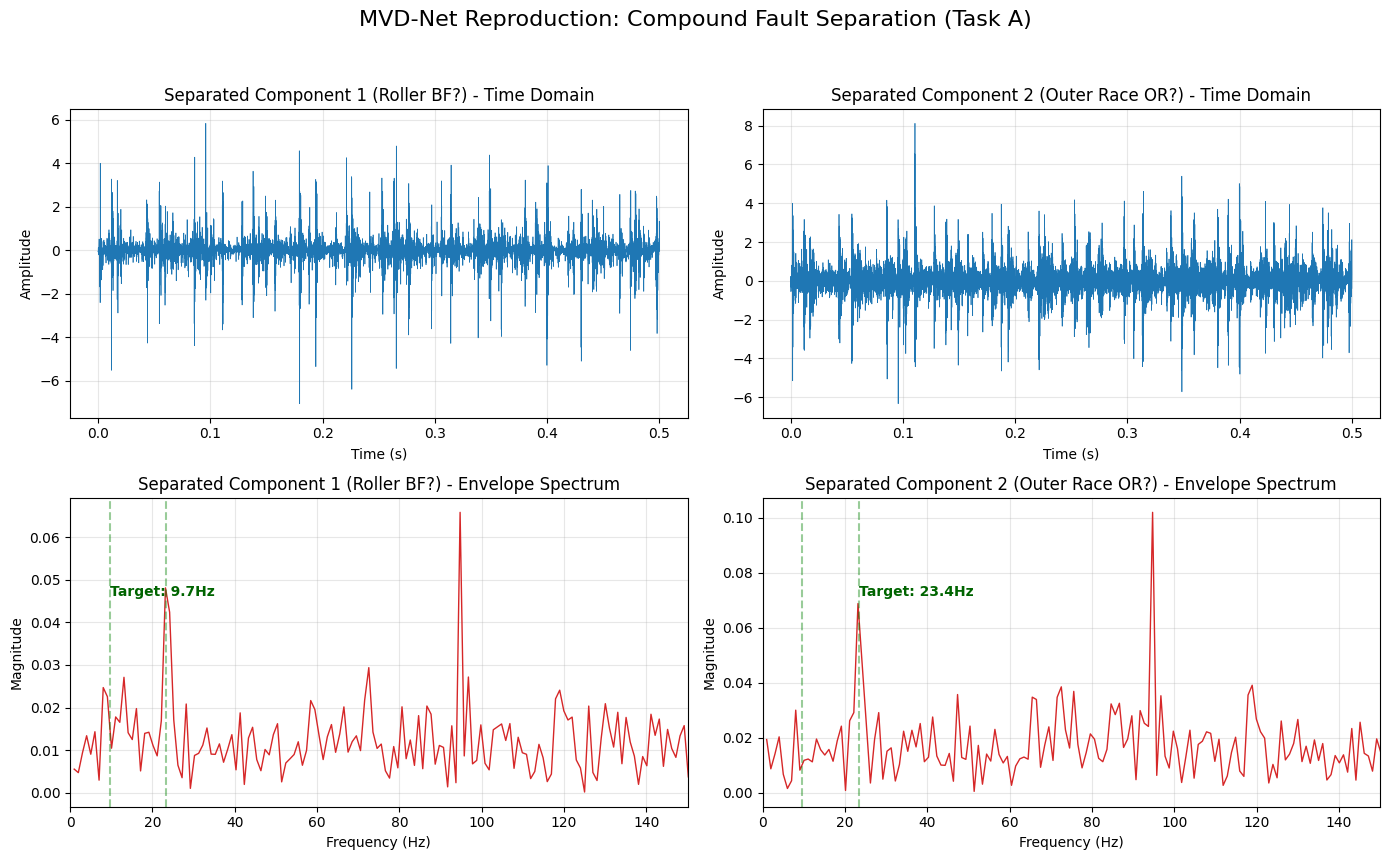

In [3]:
if __name__ == "__main__":
    # 请确保路径指向你的数据集根目录
    DATA_PATH = r"E:\BaiduNetdiskDownload\BJTU-RAO Bogie Datasets\Data\BJTU_RAO_Bogie_Datasets\BJTU_RAO_Bogie_Datasets"
    for i in range(10):
        run_training(DATA_PATH)
        plot_final_separation(DATA_PATH,save_name=i)